In [28]:
import pandas as pd
import torch
import os
import numpy as np
import matplotlib.pyplot as plt

In [29]:
from datasets import Dataset
from transformers import BertTokenizer, TrainingArguments, Trainer

In [30]:
df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/modeldata.csv")

In [31]:
print(df.columns)
print(df.shape)

Index(['verse_id', 'song_id', 'ori_track_name', 'clean_track_name',
       'all_artists', 'primary_artist', 'artist_genres', 'main_genre',
       'explicit', 'section', 'verse', 'language', 'language.1', 'confidence',
       'confidence.1', 'label'],
      dtype='str')
(22878, 16)


In [32]:
# Class balance check
print(df['label'].value_counts())

label
0    11439
1    11439
Name: count, dtype: int64


In [33]:
# Select only the columns we need
df = df[['verse', 'label']]

In [34]:
# Convert to Hugging Face format
dataset = Dataset.from_pandas(df)

In [35]:
# Fixes the [WinError 3] by explicitly setting a local cache directory
cache_dir = "C:/Users/User/Documents/devanasokan_fyp/huggingface_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

In [36]:
# Tell Hugging Face to use this directory
os.environ['HF_HOME'] = cache_dir

# This turns off the annoying symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [37]:
# Initiate with the cache path
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', cache_dir=cache_dir)

In [38]:
def preprocess_function(examples):
    # This creates the 'input_ids' and 'attention_mask' BERT needs
    return tokenizer(examples["verse"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 22878/22878 [00:03<00:00, 6001.77 examples/s]


In [39]:
# Split the dataset into training and testing sets
# Different ratios are tested
full_dataset = tokenized_dataset.train_test_split(test_size=0.3, seed=42)

In [40]:
print(full_dataset) 
# If it shows {'train': ..., 'test': ...}, it is already split!

DatasetDict({
    train: Dataset({
        features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16014
    })
    test: Dataset({
        features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6864
    })
})


In [41]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "distilbert-base-uncased" # Or any model from the Hugging Face Hub

# 1. Load the tokenizer (must match the model)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3186.92it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [42]:
import evaluate
metric = evaluate.load("accuracy")

In [43]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # argmax picks the highest probability (0 or 1)
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [44]:
# Set training arguments
training_args = TrainingArguments(
    output_dir="./results",          # Folder where checkpoints are saved
    eval_strategy="epoch",     # Run evaluation after every epoch
    save_strategy="epoch",           # Save model after every epoch
    learning_rate=2e-5,              # Standard BERT fine-tuning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    num_train_epochs=3,              # Total passes through the data
    weight_decay=0.01,               # Regularization to prevent overfitting
    load_best_model_at_end=True,     # Keeps the best version of the model
    fp16=torch.cuda.is_available()  # Use Mixed Precision if on GPU for 2x speed
)

In [45]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=full_dataset["train"],
    eval_dataset=full_dataset["test"],
    compute_metrics=compute_metrics,
)

print(trainer.compute_metrics)

<function compute_metrics at 0x0000024966E863E0>


In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
history = pd.DataFrame(trainer.state.log_history)
print(history)

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.401140   5.139456   1.668998e-05  0.499500   500        NaN   
1  0.322662   5.350299   1.335997e-05  0.999001  1000        NaN   
2       NaN        NaN            NaN  1.000000  1001   0.330469   
3  0.222860  10.335752   1.002997e-05  1.498501  1500        NaN   
4  0.215638   6.216174   6.699967e-06  1.998002  2000        NaN   
5       NaN        NaN            NaN  2.000000  2002   0.344338   
6  0.145217   7.363337   3.376623e-06  2.497502  2500        NaN   
7  0.117204  21.223907   5.328005e-08  2.997003  3000        NaN   
8       NaN        NaN            NaN  3.000000  3003   0.453106   
9       NaN        NaN            NaN  3.000000  3003        NaN   

   eval_accuracy  eval_runtime  eval_samples_per_second  \
0            NaN           NaN                      NaN   
1            NaN           NaN                      NaN   
2       0.855332       66.7954                  102.762   
3            Na

### Model Evaluation

In [63]:
# Evaluate the model on the test set
predictions = trainer.predict(full_dataset["test"])

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to predicted classes
y_pred = np.argmax(predictions.predictions, axis=-1)

In [64]:
from scipy.special import softmax

probabilities = softmax(logits, axis=1)

In [65]:
y_scores = probabilities[:, 1]

#### ROC-AUC Curve

In [66]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

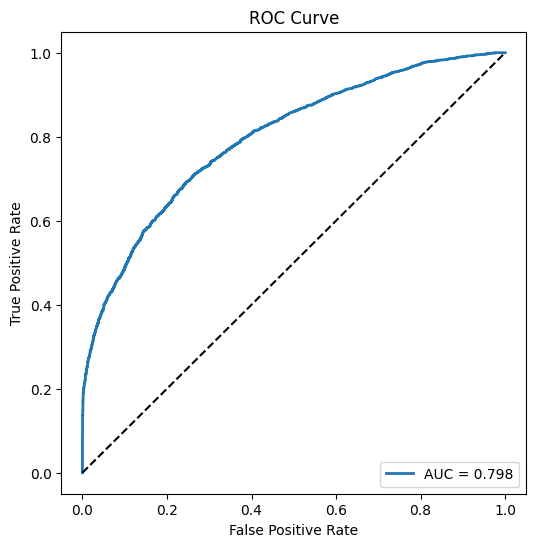

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

In [68]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

In [69]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8200598880741791


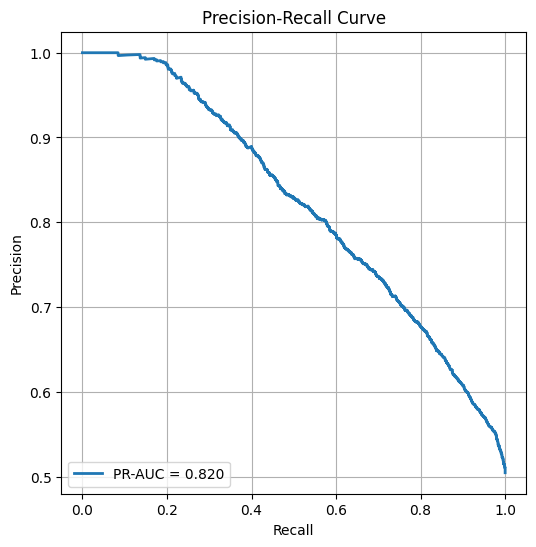

In [70]:
plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

In [62]:
from sklearn.metrics import classification_report, accuracy_score

In [71]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7134324009324009
Precision: 0.7892498066511988
Recall: 0.5893733756858215
F1-score: 0.6748222846751529


In [54]:
# Classification report
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
classification_report_output = classification_report(full_dataset["test"]["label"], np.argmax(trainer.predict(full_dataset["test"]).predictions, axis=-1))
print(classification_report_output)

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.84      0.74      3401
           1       0.79      0.59      0.67      3463

    accuracy                           0.71      6864
   macro avg       0.73      0.71      0.71      6864
weighted avg       0.73      0.71      0.71      6864



In [55]:
# Confusion Matrix

In [56]:
# Save the version currently in the trainer's brain
trainer.save_model("./my_final_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


In [57]:
# TEST MODEL

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Load the model and tokenizer from your local folder
path = "./my_final_model"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # Ensure you saved the tokenizer there too!

# Create a 'pipeline' (the easiest way to use the model)
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7643.24it/s]


In [58]:
# Test it on a new sentence
result = classifier("kiss it from my lips")
print(result)

[{'label': 'LABEL_0', 'score': 0.586175799369812}]


In [59]:
import accelerate
print(accelerate.__version__)

1.13.0


In [60]:
import accelerate
import transformers
print(f"Accelerate version: {accelerate.__version__}")
print(f"Transformers version: {transformers.__version__}")

Accelerate version: 1.13.0
Transformers version: 5.3.0


In [61]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
